# Flattened DM halo: $q$ and inclination

Held-out test of `chebconv_10params_flathalo.py`, trained on
`10p_flathalo_qi`. The two extra inference targets are the halo
axis ratio $q$ and $\cos i$; the seven DM/DF targets are the
same as the 8-parameter baseline.

Watch $q$ and $\cos i$ in particular. The simulation study
measured the projected tracer axis ratio running only from
0.997 face-on to 0.887 edge-on at $q_{\rm DM} = 0.4$, so the
signal is weak and these two may come back close to their
prior. A calibrated-but-wide posterior is the expected
outcome, not a bug -- that is precisely the difference the
rank histograms and the credible-interval widths separate.

**What is tested.** Every galaxy below comes from `data.8.h5`, the one
shard the training config never read (`num_datasets = 8` reads shards
0-7), so nothing here is a re-split of training data.

The model's own stochastic pre-transforms -- radial selection and
velocity uncertainty -- are applied exactly as in training. That matters
for the calibration claims: they hold for data drawn from the same
process the model was trained for, not for noiseless 6D truth.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, '/home/tvnguyen/projects/sbi_dsph/sbi_dsph_pipeline/npe')

import eval_utils as ev

ev.use_style()

PROJECT = '10p_flathalo_qi'
CHECKPOINT = 'last.ckpt'
N_TEST = 2000       # galaxies drawn from the held-out shard
N_SAMPLES = 1000    # posterior draws per galaxy

OUTDIR = os.environ.get(
    'EVAL_OUTDIR', f'/scratch/{os.environ["USER"]}/npe_eval/{PROJECT}')
os.makedirs(OUTDIR, exist_ok=True)
print(f'output -> {OUTDIR}')

output -> /scratch/tvnguyen/npe_eval/10p_flathalo_qi


## 1. Load the run and sample the posterior

In [2]:
run_dir = ev.find_run_dir(PROJECT)
model, config, norm_dict = ev.load_npe(run_dir, CHECKPOINT)

loader, shard = ev.load_test_set(config, norm_dict, max_graphs=N_TEST)
samples, truth = ev.sample_posterior(model, loader, num_samples=N_SAMPLES)

names = list(config.labels)
print(f'\nposterior {samples.shape}  truth {truth.shape}')
print(f'targets:      {names}')
print(f'conditioning: {list(config.get("cond_labels", []))}')

loaded last.ckpt (epoch 59)
[NPE] Flows built from scratch with 365,274 parameters



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  6.76it/s]


100%|██████████| 1/1 [00:00<00:00,  6.72it/s]

Seed set to 0


...


 88%|████████▊ | 14/16 [00:19<00:02,  1.34s/it]


 94%|█████████▍| 15/16 [00:20<00:01,  1.34s/it]


100%|██████████| 16/16 [00:21<00:00,  1.19s/it]


100%|██████████| 16/16 [00:21<00:00,  1.33s/it]


posterior (2000, 1000, 9)  truth (2000, 9)
targets:      ['dm_alpha', 'dm_beta', 'dm_gamma', 'dm_log_rdm', 'dm_log_rho0', 'df_beta0', 'df_log_ra', 'dm_q', 'cos_inc']
conditioning: ['stellar_log_rstar_kpc']


## 2. An example corner plot

One test galaxy, its posterior against the truth (red). Contours are the
68% and 95% credible regions.

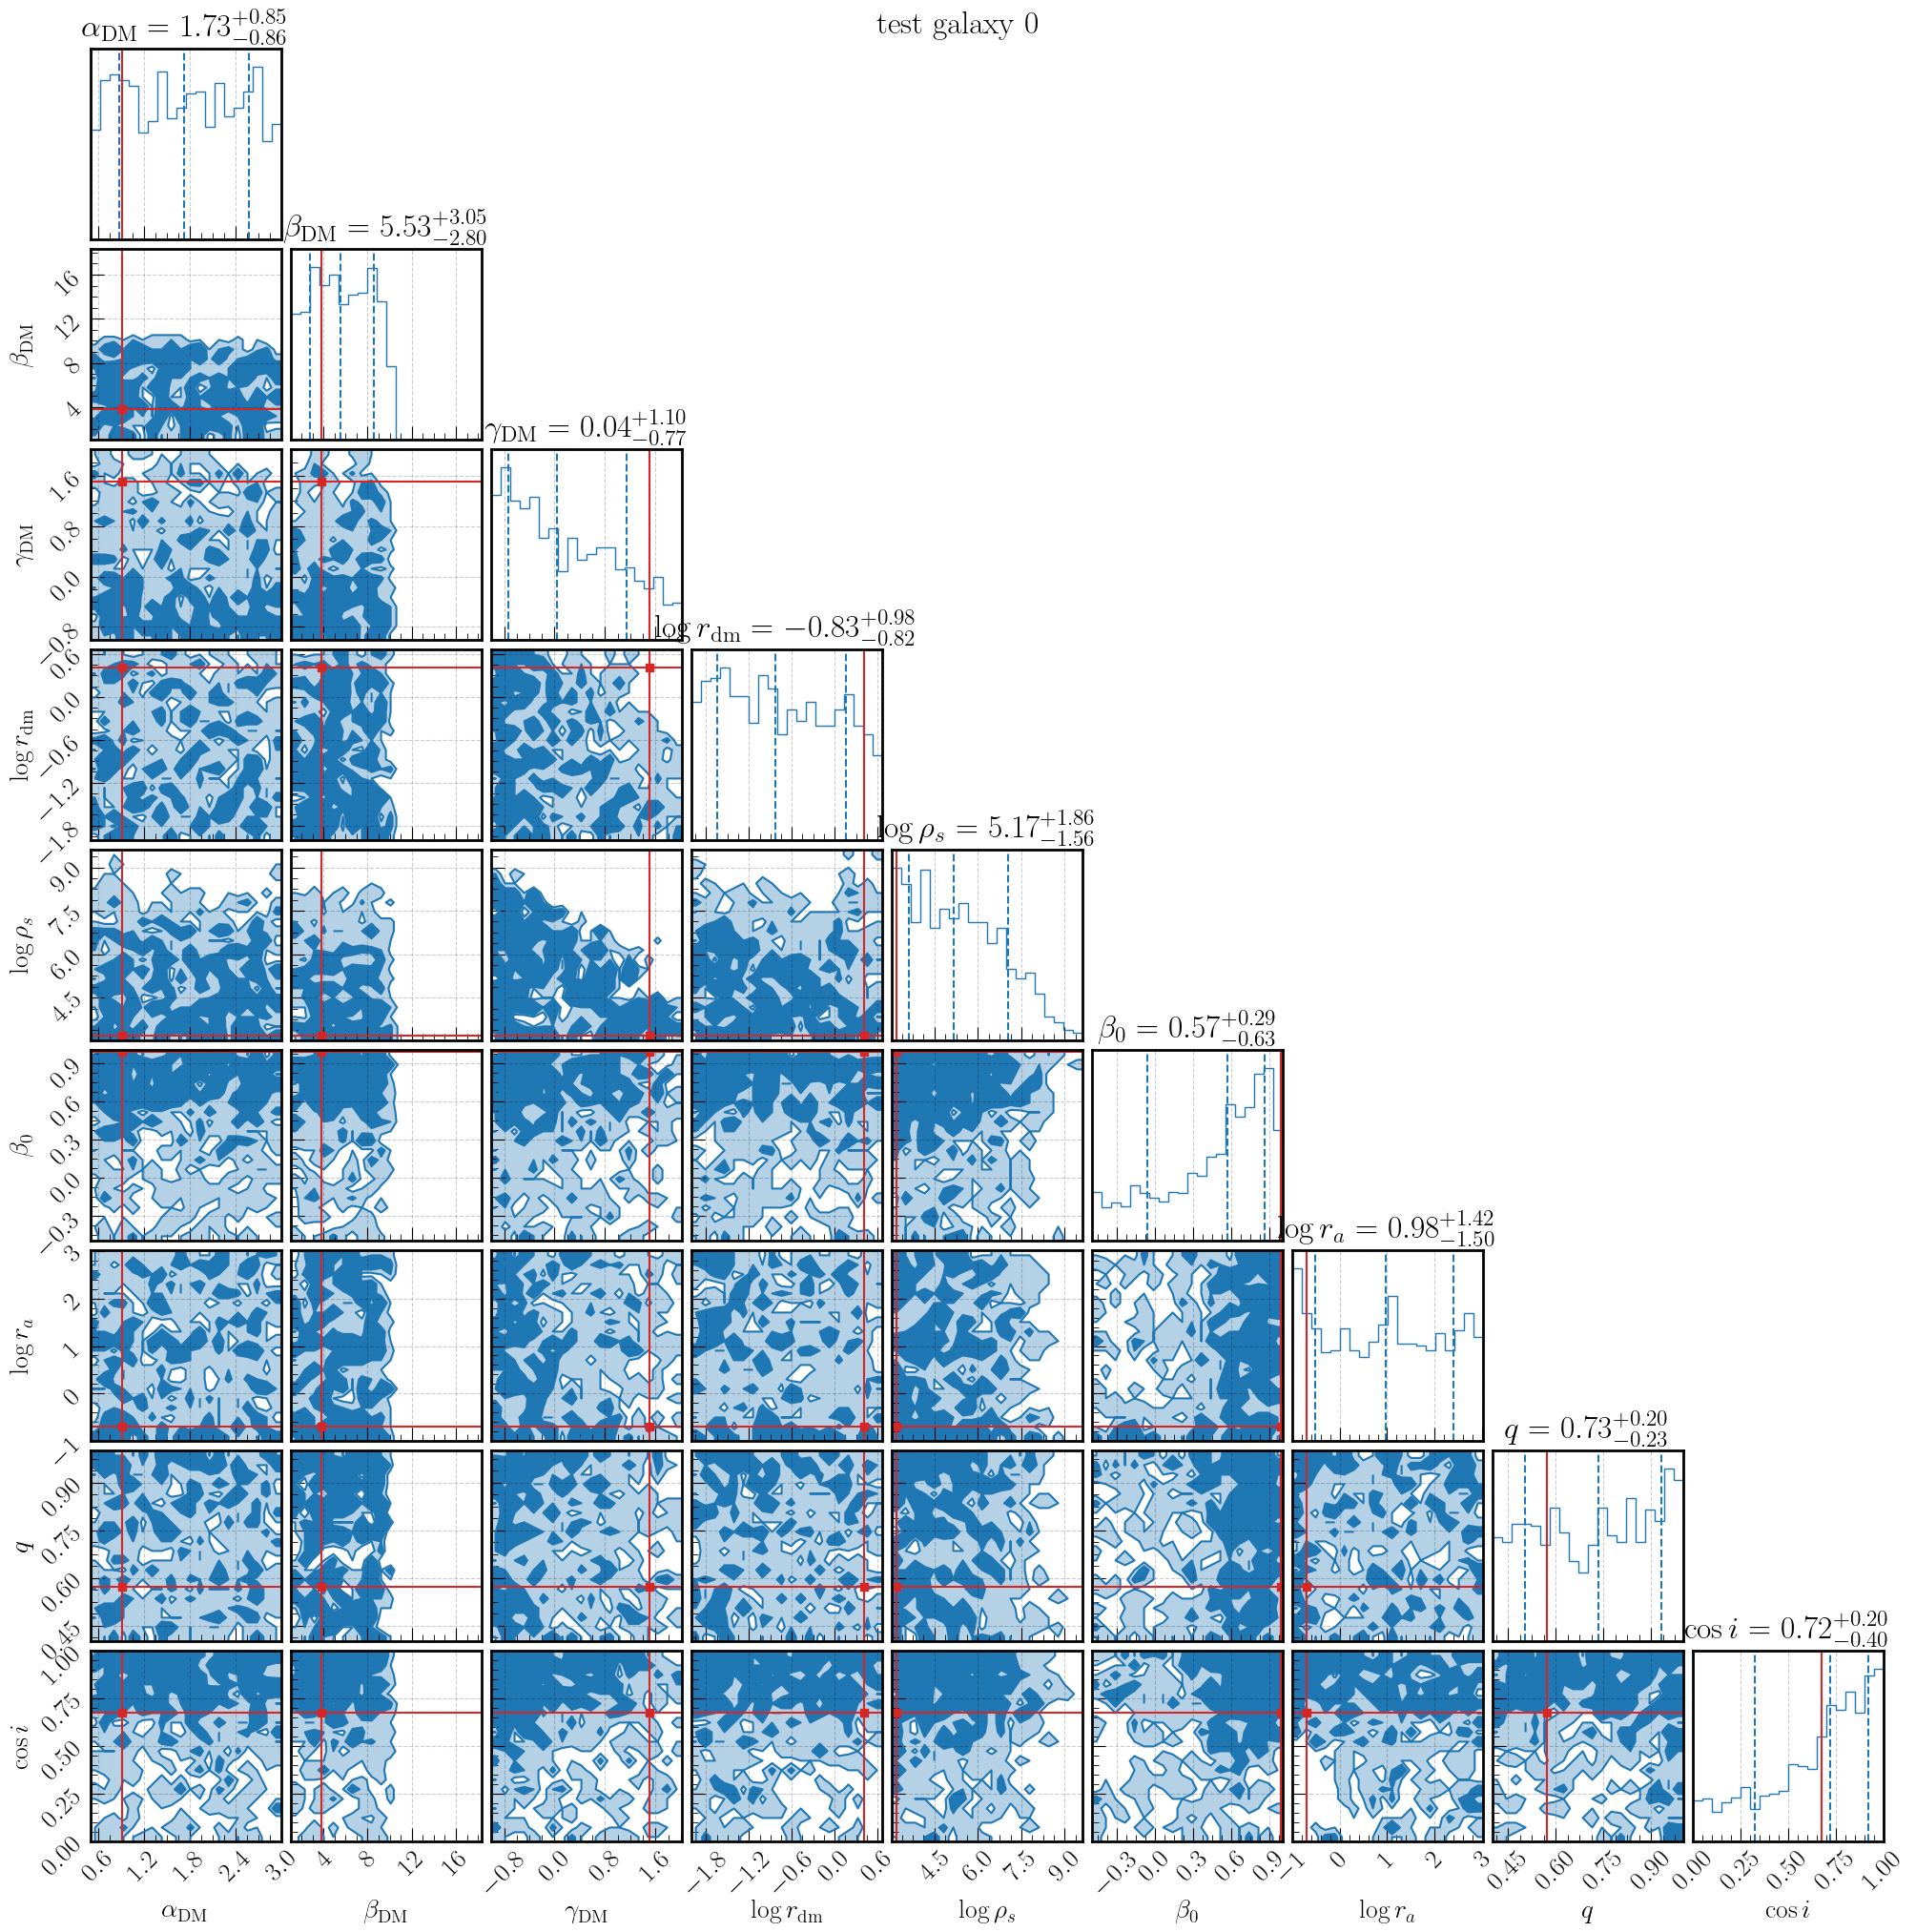

In [3]:
fig = ev.plot_corner(
    samples, truth, names, index=0,
    out_path=f'{OUTDIR}/fig1_corner_example.png')
plt.show()

## 3. Posterior median vs truth

Error bars are the 68% credible interval. `width_over_prior` is the mean
interval width divided by the full prior range -- the honest measure of
how much each parameter was actually learned. A value near 1 means the
posterior is telling you roughly what the prior already did.

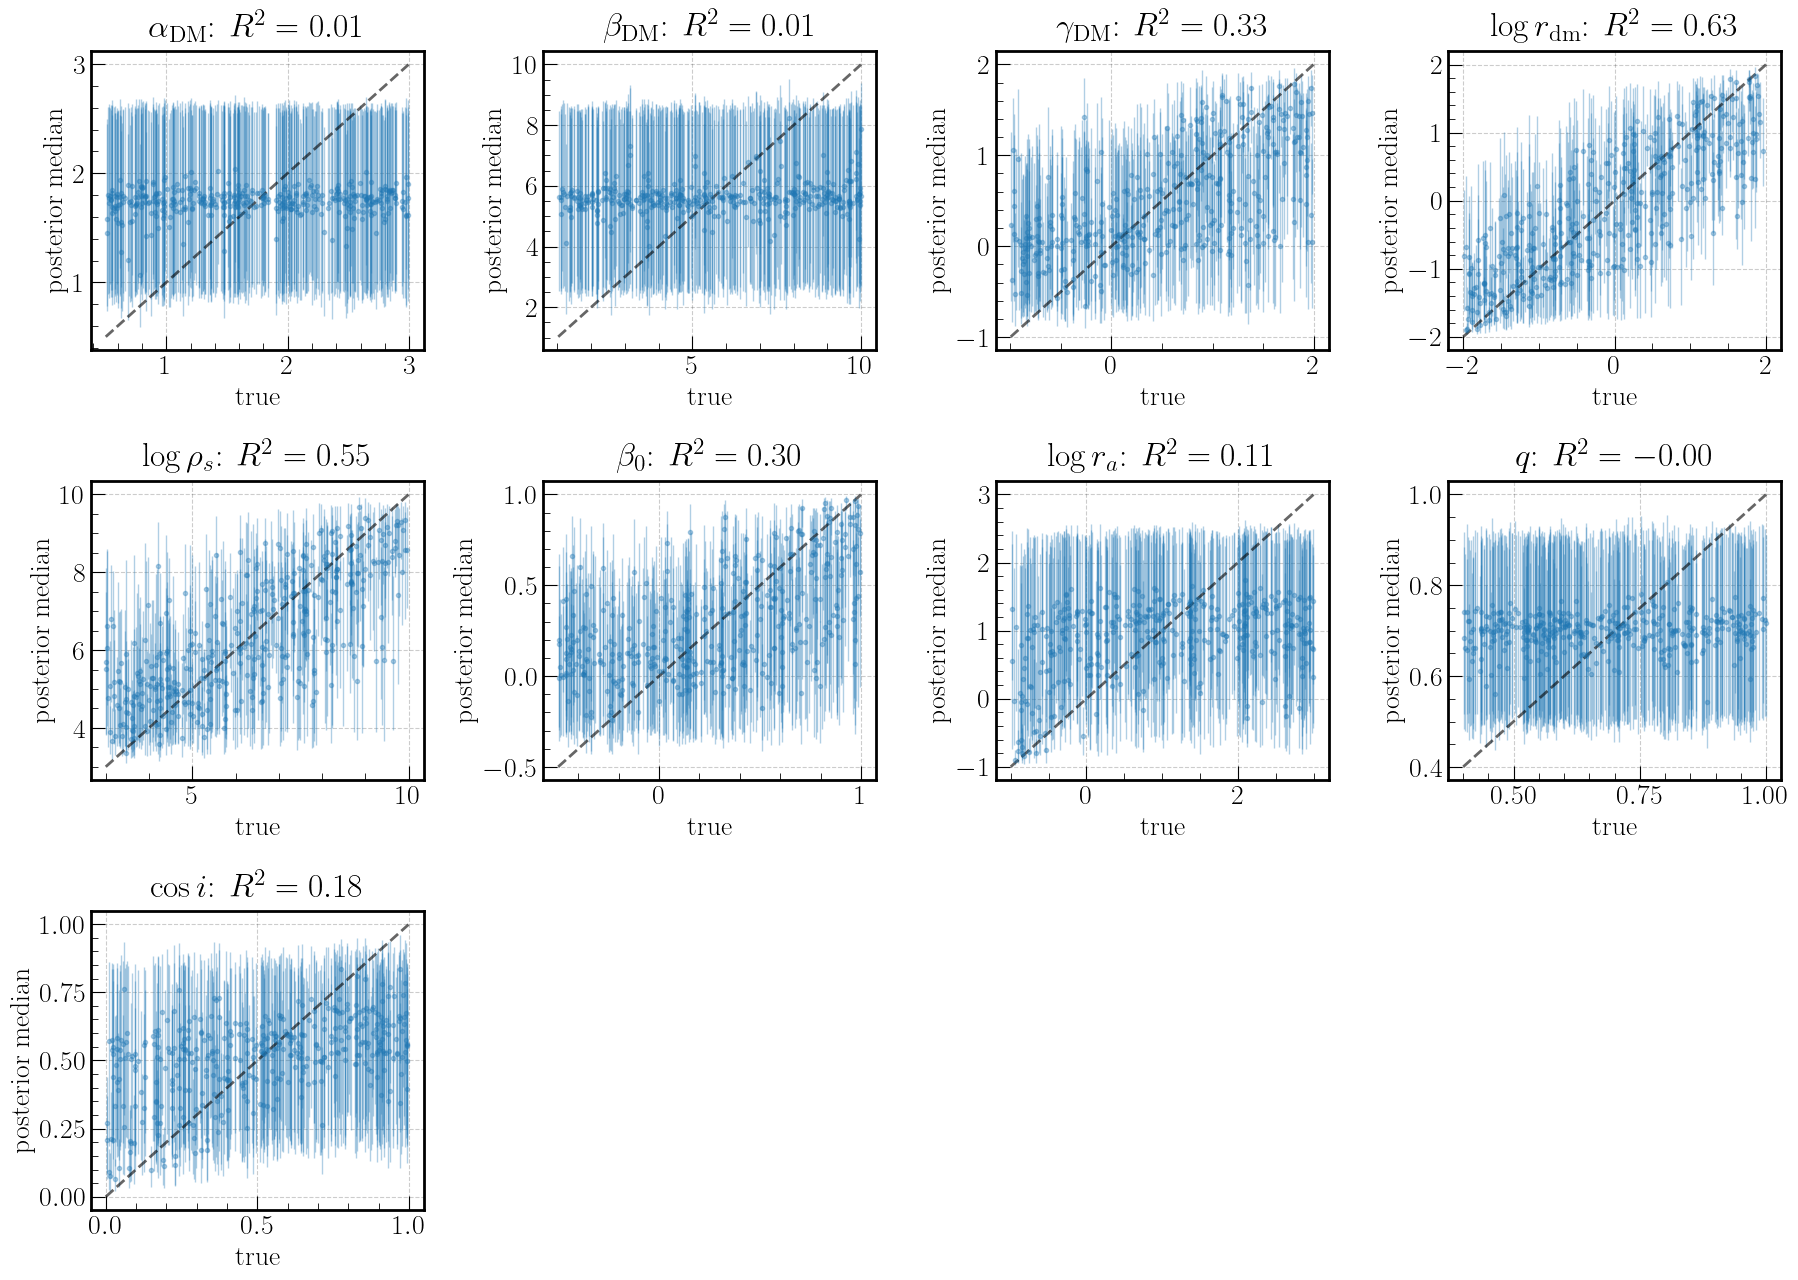

parameter                     R2     bias  scatter  68% width   /prior
dm_alpha                   0.007    0.036    0.711      1.684     0.68
dm_beta                    0.014   -0.077    2.594      5.923     0.66
dm_gamma                   0.325   -0.023    0.685      1.461     0.49
dm_log_rdm                 0.635   -0.037    0.672      1.454     0.36
dm_log_rho0                0.547   -0.006    1.332      2.706     0.39
df_beta0                   0.298    0.021    0.367      0.777     0.52
df_log_ra                  0.107   -0.081    1.094      2.467     0.62
dm_q                      -0.003    0.003    0.173      0.400     0.67
cos_inc                    0.177    0.007    0.260      0.579     0.58


In [4]:
fig, stats = ev.plot_pred_vs_true(
    samples, truth, names, out_path=f'{OUTDIR}/fig2_pred_vs_true.png')
plt.show()

print(f'{"parameter":<24s} {"R2":>7s} {"bias":>8s} '
      f'{"scatter":>8s} {"68% width":>10s} {"/prior":>8s}')
for name, s in stats.items():
    print(f'{name:<24s} {s["r2"]:7.3f} {s["bias"]:8.3f} '
          f'{s["scatter"]:8.3f} {s["width68"]:10.3f} '
          f'{s["width_over_prior"]:8.2f}')

## 4. Calibration I -- TARP

TARP tests the *joint* posterior: it draws random reference points and
checks that credible regions contain the truth as often as they claim.
A calibrated model tracks the diagonal. Bands are 1-3 sigma bootstrap.


  0%|          | 0/100 [00:00<?, ?it/s]


  1%|          | 1/100 [00:00<01:04,  1.53it/s]


  2%|▏         | 2/100 [00:01<00:55,  1.78it/s]


  3%|▎         | 3/100 [00:02<01:19,  1.23it/s]


  4%|▍         | 4/100 [00:02<00:57,  1.68it/s]

...


 97%|█████████▋| 97/100 [00:20<00:00,  5.21it/s]


 98%|█████████▊| 98/100 [00:20<00:00,  4.43it/s]


 99%|█████████▉| 99/100 [00:20<00:00,  4.11it/s]


100%|██████████| 100/100 [00:21<00:00,  3.68it/s]


100%|██████████| 100/100 [00:21<00:00,  4.74it/s]

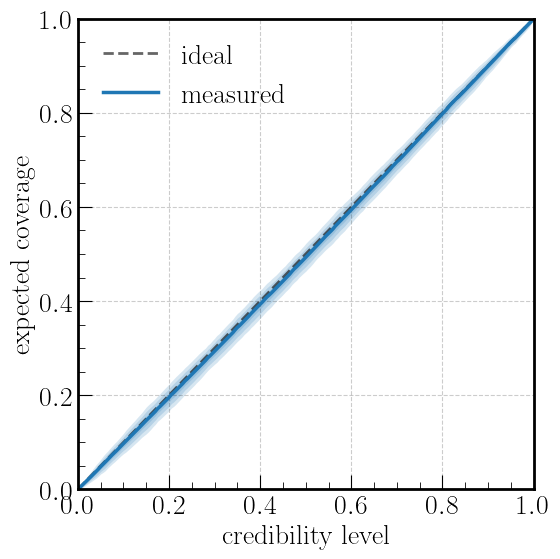

max |coverage - credibility| = 0.0078


In [5]:
fig, tarp_dev = ev.plot_tarp(
    samples, truth, out_path=f'{OUTDIR}/fig3_tarp.png')
plt.show()
print(f'max |coverage - credibility| = {tarp_dev:.4f}')

## 5. Calibration II -- rank-based marginals

For each parameter, the rank of the truth among the posterior draws.
Uniform means calibrated; a U shape means the posterior is too narrow, a
dome means too wide, and a slope means it is biased. The grey band is
the 2-sigma binomial spread expected from a uniform histogram, and
chi2_nu is the reduced chi-square against uniform (1 is ideal).

TARP tests the joint, this tests each marginal -- a model can pass one
and fail the other, so they are worth reading together.

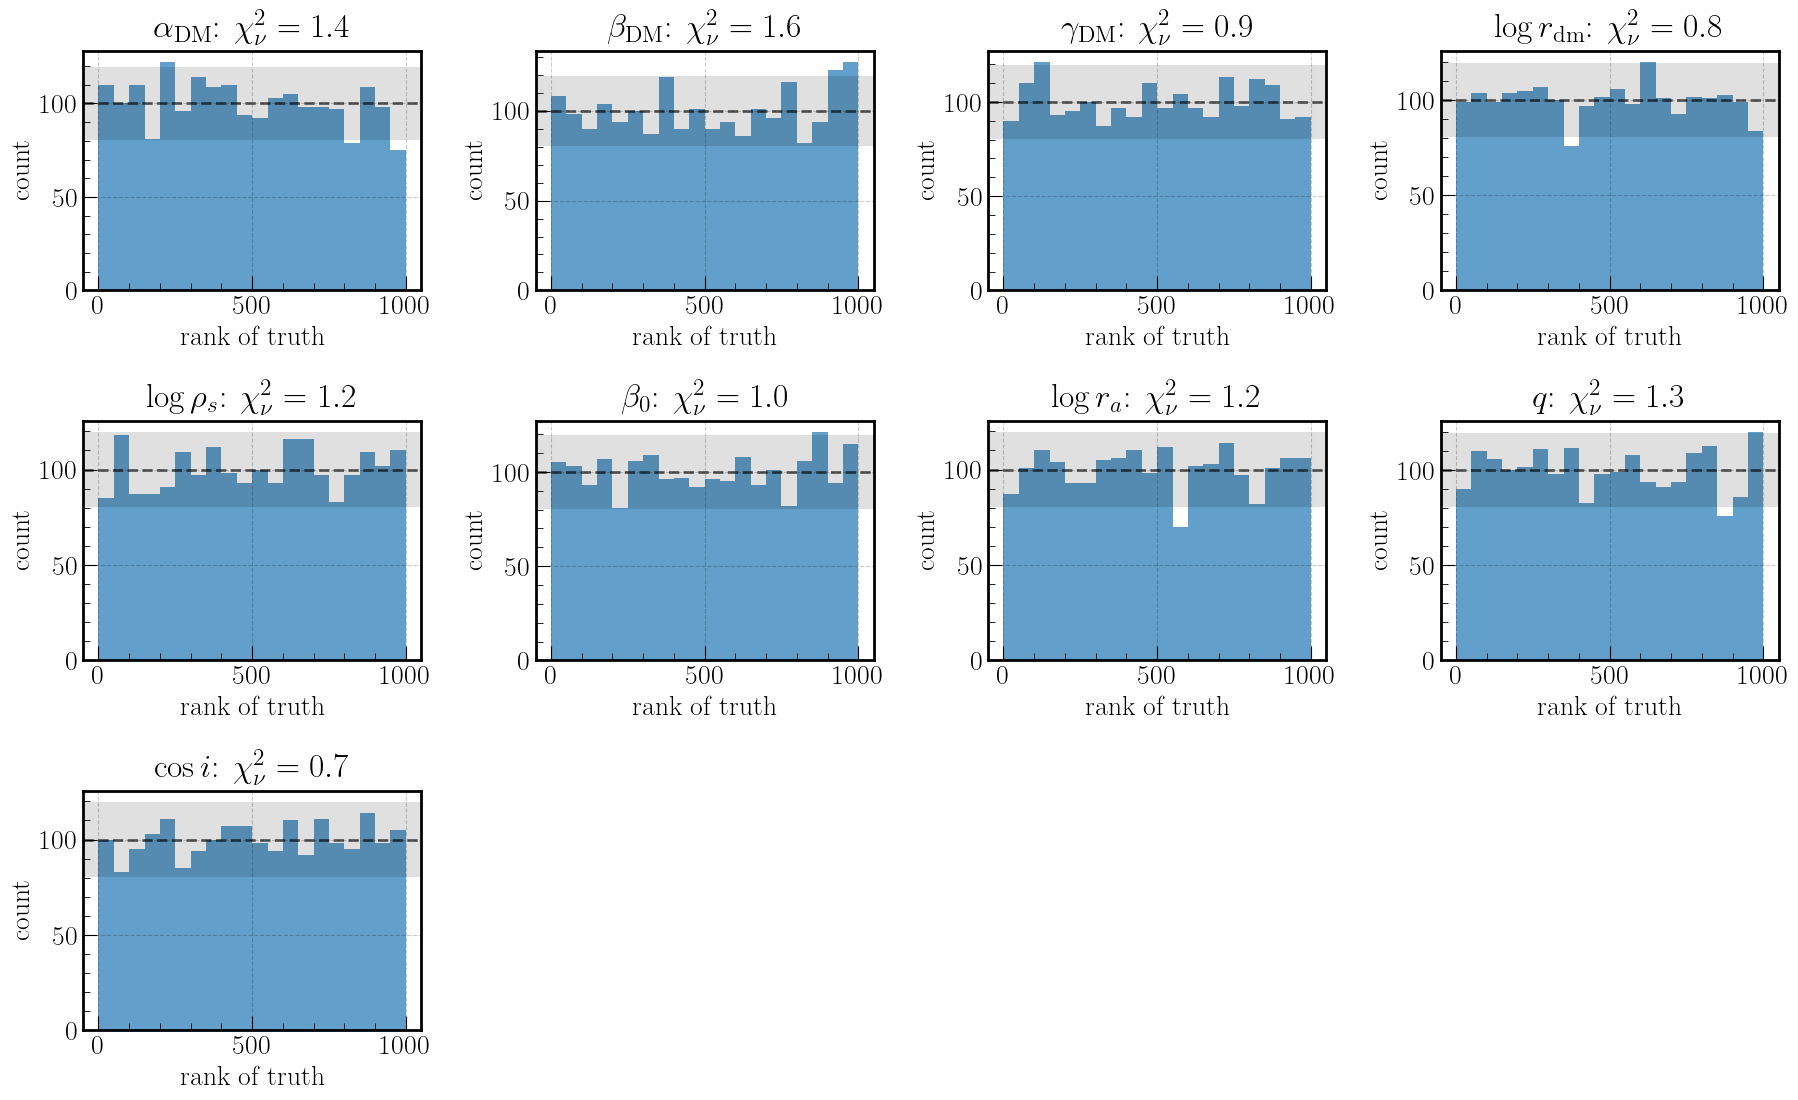

dm_beta                  chi2_nu =   1.62
dm_alpha                 chi2_nu =   1.44
dm_q                     chi2_nu =   1.29
dm_log_rho0              chi2_nu =   1.21
df_log_ra                chi2_nu =   1.16
df_beta0                 chi2_nu =   1.01
dm_gamma                 chi2_nu =   0.89
dm_log_rdm               chi2_nu =   0.77
cos_inc                  chi2_nu =   0.73


In [6]:
fig, chi2 = ev.plot_rank_marginals(
    samples, truth, names, out_path=f'{OUTDIR}/fig4_rank_marginals.png')
plt.show()
for name, c in sorted(chi2.items(), key=lambda kv: -kv[1]):
    print(f'{name:<24s} chi2_nu = {c:6.2f}')

## 6. Calibration III -- correlations between parameters

Sections 3 and 5 look at one parameter at a time, and TARP collapses the
joint to a single scalar. All three can pass while the posterior states
the wrong *correlation*. On a conjugate-Gaussian control where the true
posterior correlation was deliberately zeroed, the 1-D rank histograms
stayed at chi2_nu = 0.70 and 1.45 -- perfectly healthy -- while the
difference-direction test below rose to 10.0.

**Left panel** is the posterior correlation averaged over test galaxies:
descriptive, it says which degeneracies the model reports. **Right
panel** whitens each galaxy's error by its own posterior covariance, so
a correctly-shaped posterior gives the identity; off-diagonal structure
means the reported correlation is wrong.

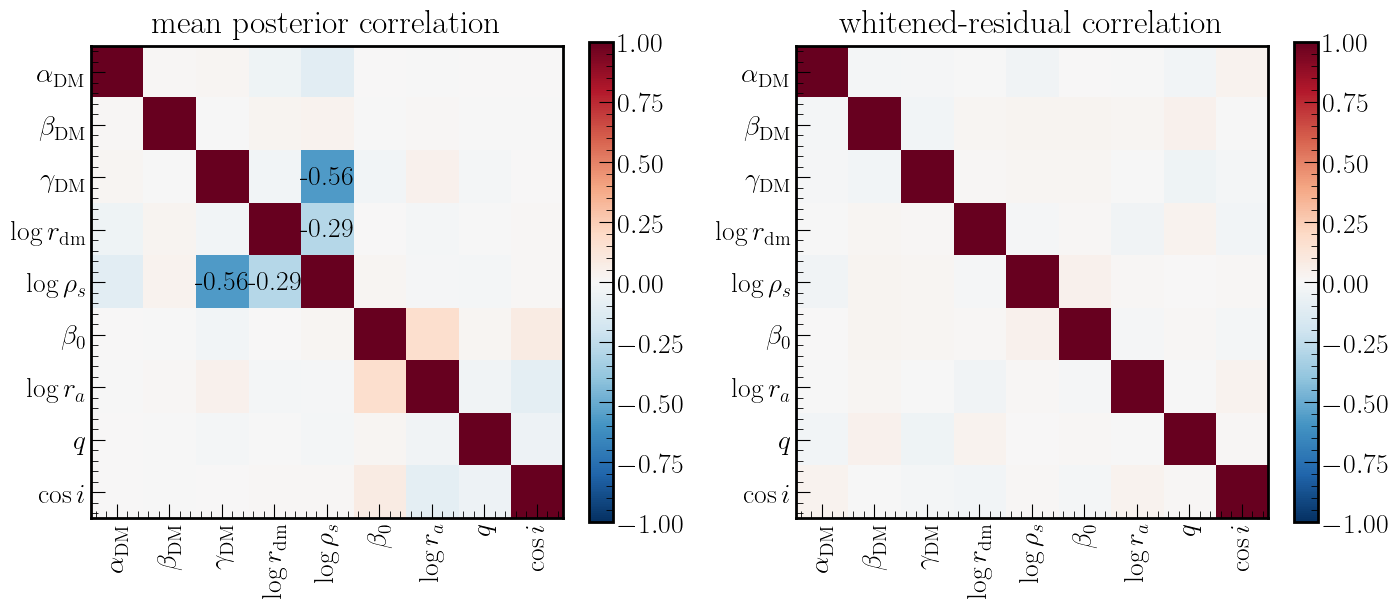

largest |off-diagonal| of whitened residual correlation: 0.043
whitened variance per parameter (1.0 = calibrated width):
  dm_alpha                 0.978
  dm_beta                  1.044
  dm_gamma                 0.965
  dm_log_rdm               0.971
  dm_log_rho0              1.070
  df_beta0                 1.013
  df_log_ra                0.994
  dm_q                     1.025
  cos_inc                  1.013

strongest degeneracies the posterior reports:
  dm_gamma               dm_log_rho0            r = -0.56
  dm_log_rdm             dm_log_rho0            r = -0.29
  df_beta0               df_log_ra              r = +0.17
  dm_alpha               dm_log_rho0            r = -0.10
  df_log_ra              cos_inc                r = -0.10
  df_beta0               cos_inc                r = +0.08


In [7]:
fig, corr = ev.plot_correlation_matrices(
    samples, truth, names, out_path=f'{OUTDIR}/fig5_correlations.png')
plt.show()
print(f'largest |off-diagonal| of whitened residual correlation: '
      f'{corr["max_offdiag"]:.3f}')
print('whitened variance per parameter (1.0 = calibrated width):')
for name, v in zip(names, corr['whitened_var']):
    print(f'  {name:<24s} {v:.3f}')

pc = corr['posterior_corr']
iu = np.triu_indices(len(names), k=1)
order = np.argsort(-np.abs(pc[iu]))
print()
print('strongest degeneracies the posterior reports:')
for k in order[:6]:
    i, j = iu[0][k], iu[1][k]
    print(f'  {names[i]:<22s} {names[j]:<22s} r = {pc[i, j]:+.2f}')

The whitening above assumes the posterior is roughly Gaussian. This next
test does not: if the joint posterior is calibrated, the rank of the
truth is uniform along **any** fixed direction in parameter space, not
only along the coordinate axes. Squeezing or stretching the
`theta_i - theta_j` direction is exactly what a mis-stated correlation
does, while leaving both 1-D marginals untouched.

Difference directions are below the diagonal, sum directions above it,
and the single-parameter values on the diagonal (these match section 5).

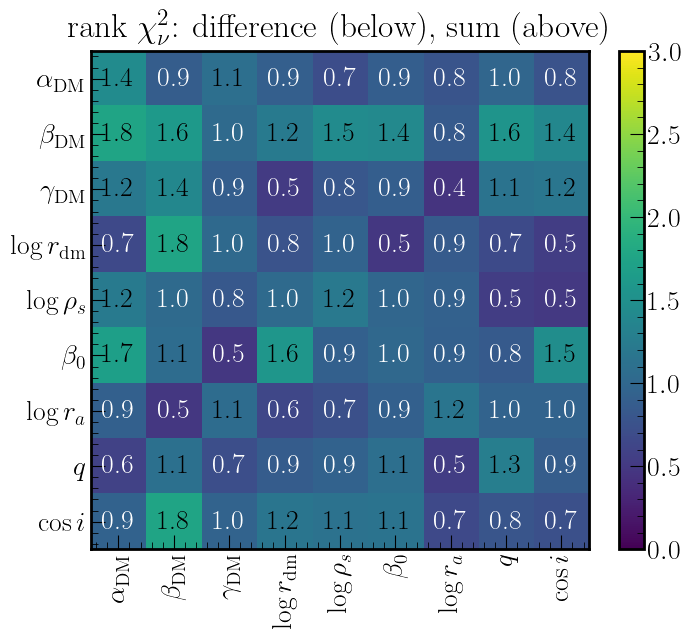

worst combination: cos_inc vs dm_beta  chi2_nu = 1.75
200 random directions: median chi2_nu 0.98, max 2.23, fraction above 2.0 = 0.01


In [8]:
fig, pair = ev.plot_pairwise_rank_calibration(
    samples, truth, names,
    out_path=f'{OUTDIR}/fig6_pairwise_rank.png')
plt.show()
w = pair['worst_pair']
print(f'worst combination: {w[0]} vs {w[1]}  chi2_nu = {w[2]:.2f}')
print(f'200 random directions: median chi2_nu '
      f'{pair["random_median"]:.2f}, max {pair["random_max"]:.2f}, '
      f'fraction above 2.0 = {pair["random_frac_above_2"]:.2f}')

## 7. Calibration IV -- MIRA

MIRA is built like TARP but returns a single number, higher being
better and 1 the ceiling. It scores **calibration, not
informativeness**: a posterior that just returns the prior is perfectly
calibrated and scores as well as a sharp one. That is why the prior
baseline below is a *reference*, not a floor -- if the model matches it,
that means calibrated, and section 3's widths are what say whether the
posterior is also useful.

The two miscalibrated controls take the model's own posterior and
rescale it about its median by 3x and 1/3. Both should score clearly
lower, and how much lower sets the scale for reading the model's number.

In [9]:
mira = ev.mira_scores(samples, truth, num_runs=100)
for name, (score, std) in mira.items():
    print(f'{name:<20s} {score:.4f} +/- {std:.4f}')

model                0.6661 +/- 0.0050
model x3 broader     0.5100 +/- 0.0064
model /3 sharper     0.5491 +/- 0.0066
prior baseline       0.6667 +/- 0.0050


## Summary

In [10]:
worst = max(chi2.items(), key=lambda kv: kv[1])
tightest = min(stats.items(), key=lambda kv: kv[1]['width_over_prior'])
loosest = max(stats.items(), key=lambda kv: kv[1]['width_over_prior'])

print(f'run           {run_dir.name} ({CHECKPOINT})')
print(f'test set      {truth.shape[0]} galaxies from data.{shard}.h5')
print(f'TARP          max deviation {tarp_dev:.4f}')
print(f'ranks         worst chi2_nu {worst[1]:.2f} ({worst[0]})')
print(f'correlations  max |off-diag| {corr["max_offdiag"]:.3f}; '
      f'worst pair {pair["worst_pair"][2]:.2f} '
      f'({pair["worst_pair"][0]} vs {pair["worst_pair"][1]})')
print(f'random dirs   median chi2_nu {pair["random_median"]:.2f}, '
      f'max {pair["random_max"]:.2f}')
print(f'MIRA          {mira["model"][0]:.4f} vs '
      f'{mira["prior baseline"][0]:.4f} prior, '
      f'{mira["model x3 broader"][0]:.4f} broadened')
print(f'best measured {tightest[0]} '
      f'({tightest[1]["width_over_prior"]:.2f} of prior range)')
print(f'least        {loosest[0]} '
      f'({loosest[1]["width_over_prior"]:.2f} of prior range)')

run           99g4k610 (last.ckpt)
test set      2000 galaxies from data.8.h5
TARP          max deviation 0.0078
ranks         worst chi2_nu 1.62 (dm_beta)
correlations  max |off-diag| 0.043; worst pair 1.75 (cos_inc vs dm_beta)
random dirs   median chi2_nu 0.98, max 2.23
MIRA          0.6661 vs 0.6667 prior, 0.5100 broadened
best measured dm_log_rdm (0.36 of prior range)
least        dm_alpha (0.68 of prior range)
